# Machine Learning Course - Project.

## Part 3: Association Rule Learning - Discovering Patterns

In [ ]:
!pip install pandas mlxtend matplotlib networkx


**Import Necessary Libraries**

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import networkx as nx


**Load and Explore the Groceries Dataset**

In [ ]:
# Specify the delimiter as a semicolon or try the 'infer' option
df = pd.read_csv(url, delimiter=';')
df.head()


,"citrus fruit,semi-finished bread,margarine,ready soups"
0,"tropical fruit,yogurt,coffee"
1,whole milk
2,"pip fruit,yogurt,cream cheese ,meat spreads"
3,"other vegetables,whole milk,condensed milk,lon..."
4,"whole milk,butter,yogurt,rice,abrasive cleaner"


**Convert Transactional Data to a List of Lists**

In [ ]:
# Split the single column into a list of transactions
transactions = df[df.columns[0]].apply(lambda x: x.split(','))

# Display the first few transactions
transactions.head()


,"citrus fruit,semi-finished bread,margarine,ready soups"
0,"[tropical fruit, yogurt, coffee]"
1,[whole milk]
2,"[pip fruit, yogurt, cream cheese , meat spreads]"
3,"[other vegetables, whole milk, condensed milk,..."
4,"[whole milk, butter, yogurt, rice, abrasive cl..."


**Convert to One-Hot Encoded Matrix Format**

In [ ]:
from mlxtend.preprocessing import TransactionEncoder

# Transform transactions into a binary matrix
te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_data, columns=te.columns_)

# Show the first few rows of the binary matrix
df_encoded.head()


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False


**Apriori Algorithm**

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

# Generate frequent itemsets using the Apriori algorithm
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)
frequent_itemsets.head()

# Generate strong association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
rules = rules.sort_values(by=['confidence', 'lift'], ascending=[False, False])
rules.head()


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
530,"(root vegetables, citrus fruit)",(other vegetables),0.017694,0.193512,0.010372,0.586207,3.029300,1.0,0.006948,1.949012,0.681957,0.051646,0.486920,0.319903
366,"(root vegetables, tropical fruit)",(other vegetables),0.021049,0.193512,0.012304,0.584541,3.020692,1.0,0.008231,1.941197,0.683334,0.060835,0.484854,0.324062
587,"(yogurt, curd)",(whole milk),0.017287,0.255542,0.010067,0.582353,2.278893,1.0,0.005650,1.782505,0.571062,0.038313,0.438992,0.310874
428,"(butter, other vegetables)",(whole milk),0.020033,0.255542,0.011491,0.573604,2.244657,1.0,0.006372,1.745931,0.565833,0.043512,0.427240,0.309285
388,"(root vegetables, tropical fruit)",(whole milk),0.021049,0.255542,0.011999,0.570048,2.230742,1.0,0.006620,1.731492,0.563582,0.045350,0.422463,0.308502


**Visualize the Results**

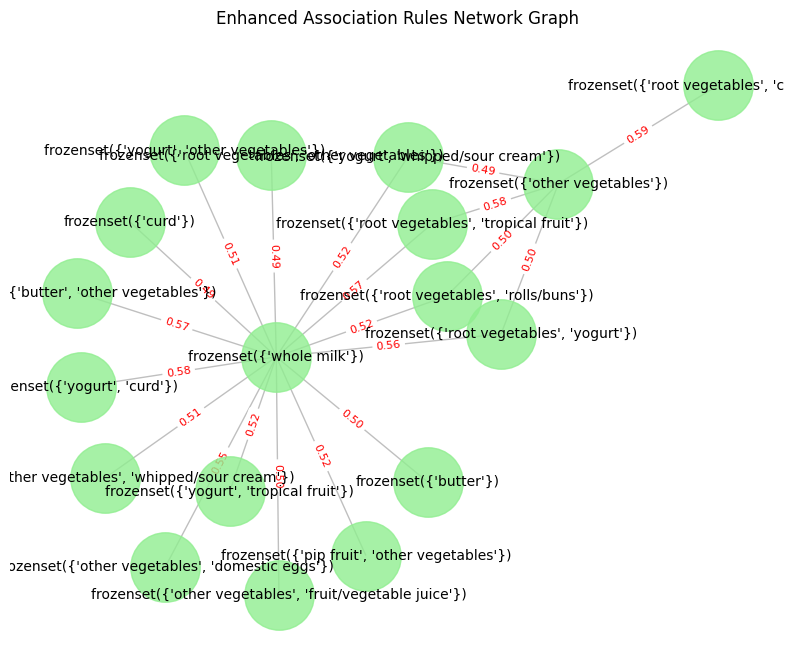

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Create an enhanced network graph of the top 20 association rules
plt.figure(figsize=(10, 8))
G = nx.from_pandas_edgelist(
    rules.head(20),
    source='antecedents',
    target='consequents',
    edge_attr=True
)

# Improve layout and appearance
pos = nx.spring_layout(G, seed=42)

# Draw nodes with color coding
antecedent_nodes = [node for node in G.nodes if "{" not in str(node)]
consequent_nodes = [node for node in G.nodes if "{" in str(node)]

# Draw nodes with different colors
nx.draw_networkx_nodes(G, pos, nodelist=antecedent_nodes, node_color='skyblue', node_size=3000, alpha=0.8)
nx.draw_networkx_nodes(G, pos, nodelist=consequent_nodes, node_color='lightgreen', node_size=2500, alpha=0.8)

# Draw edges with confidence as labels
nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color='grey')
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif', font_color='black')

# Add edge labels (rounded confidence values)
edge_labels = nx.get_edge_attributes(G, 'confidence')
edge_labels = {k: f"{v:.2f}" for k, v in edge_labels.items()}  # Round to 2 decimal places
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)

# Add a clear title and remove axis
plt.title('Enhanced Association Rules Network Graph')
plt.axis('off')
plt.show()


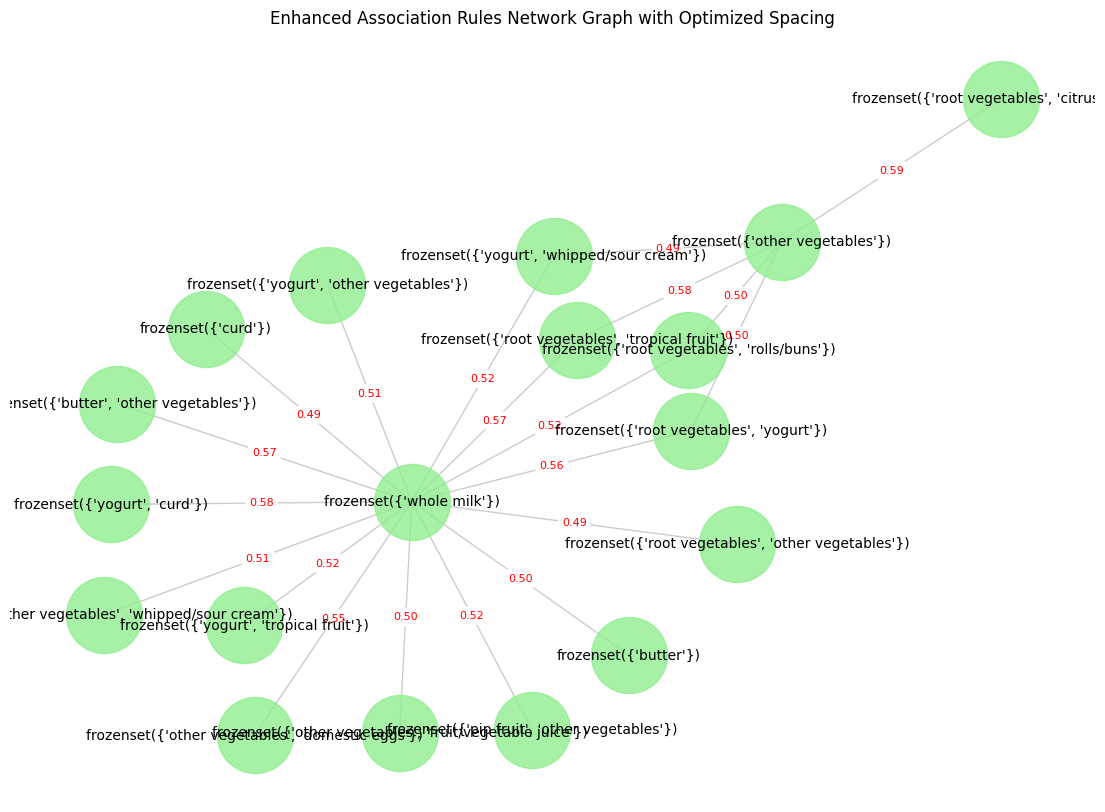

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Create an enhanced network graph of the top 20 association rules
plt.figure(figsize=(14, 10))
G = nx.from_pandas_edgelist(
    rules.head(20),
    source='antecedents',
    target='consequents',
    edge_attr=True
)

# Use a spring layout with increased spacing
pos = nx.spring_layout(G, seed=42, k=0.5)  # k is the optimal distance between nodes

# Draw nodes with improved layout and color coding
antecedent_nodes = [node for node in G.nodes if "{" not in str(node)]
consequent_nodes = [node for node in G.nodes if "{" in str(node)]

# Draw nodes with distinct colors and increased size for better visibility
nx.draw_networkx_nodes(G, pos, nodelist=antecedent_nodes, node_color='skyblue', node_size=3500, alpha=0.8)
nx.draw_networkx_nodes(G, pos, nodelist=consequent_nodes, node_color='lightgreen', node_size=3000, alpha=0.8)

# Draw edges and labels
nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='grey')
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif', font_color='black')

# Add edge labels (rounded confidence values) with better positioning
edge_labels = nx.get_edge_attributes(G, 'confidence')
edge_labels = {k: f"{v:.2f}" for k, v in edge_labels.items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8, rotate=False)

# Add title and remove axis for a clean look
plt.title('Enhanced Association Rules Network Graph with Optimized Spacing')
plt.axis('off')
plt.show()


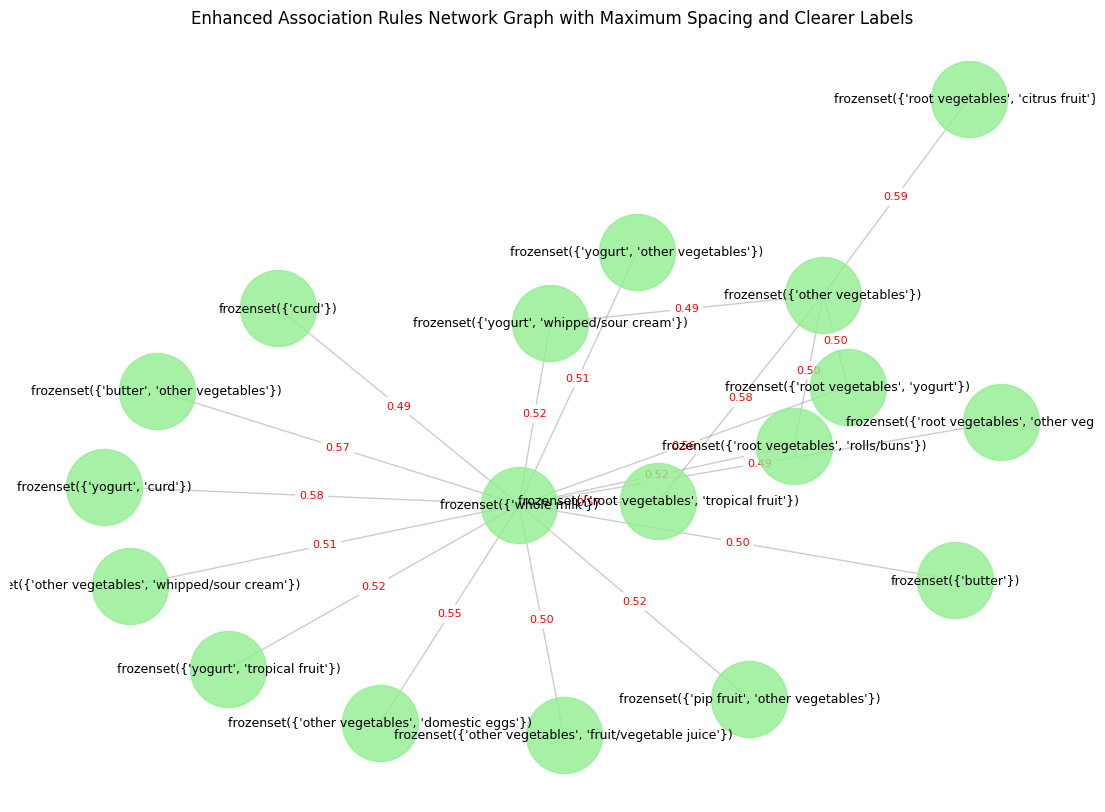

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Create an enhanced network graph of the top 20 association rules
plt.figure(figsize=(14, 10))
G = nx.from_pandas_edgelist(
    rules.head(20),
    source='antecedents',
    target='consequents',
    edge_attr=True
)

# Use a spring layout with increased spacing
pos = nx.spring_layout(G, seed=42, k=0.7)  # Increased k value for more spacing

# Draw nodes with improved layout and color coding
antecedent_nodes = [node for node in G.nodes if "{" not in str(node)]
consequent_nodes = [node for node in G.nodes if "{" in str(node)]

# Draw nodes with distinct colors and increased size for better visibility
nx.draw_networkx_nodes(G, pos, nodelist=antecedent_nodes, node_color='skyblue', node_size=3500, alpha=0.8)
nx.draw_networkx_nodes(G, pos, nodelist=consequent_nodes, node_color='lightgreen', node_size=3000, alpha=0.8)

# Draw edges and labels
nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color='grey')
nx.draw_networkx_labels(G, pos, font_size=9, font_family='sans-serif', font_color='black')

# Add edge labels (rounded confidence values) with better positioning
edge_labels = nx.get_edge_attributes(G, 'confidence')
edge_labels = {k: f"{v:.2f}" for k, v in edge_labels.items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8, rotate=False)

# Add title and remove axis for a clean look
plt.title('Enhanced Association Rules Network Graph with Maximum Spacing and Clearer Labels')
plt.axis('off')
plt.show()
